# ShopAssist AI — Agentic Routing: Fine-Tuning Transformers for Intent Classification

Two candidate routing strategies benchmarked on the Bitext Customer Support dataset (11 categories, 26,872 examples):

- **Approach 1** — Encoder-only transformers (BERT, DistilBERT, RoBERTa, ModernBERT) fine-tuned as classifiers
- **Approach 2** — Decoder-only SLMs (Qwen2.5-0.5B/1.5B-Instruct) fine-tuned with LoRA, framed as constrained generation

Runtime: Google Colab, T4 GPU (~15GB VRAM). All splits stratified by `category`, `random_seed=0`. Test set touched exactly once per model, at final evaluation only.

**Note on class count:** the task brief's Approach 1 instructions say "10-class classifier" but the agent roster and dataset both define **11** categories. Treated as 11 classes throughout — the "10" is an inconsistency in the brief, not a dataset property.

*(Split: Part A — Approach 1 (Encoders))*

## 0. Setup

In [4]:
!pip install -q transformers datasets peft accelerate evaluate scikit-learn matplotlib seaborn bitsandbytes huggingface_hub -U

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 784.9/784.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.7 MB/s eta 0:00:00


In [5]:
import os, random, time, json, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_recall_fscore_support, accuracy_score,
    confusion_matrix, classification_report
)

SEED = 0
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

Device: cuda
GPU: Tesla T4
Total VRAM: 15.64 GB


In [6]:
def reset_gpu():
    # Free VRAM between model runs — required on T4 to fit 6 models sequentially.
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()
    if torch.cuda.is_available():
        print(f"Post-reset allocated: {torch.cuda.memory_allocated()/1e6:.1f} MB")

## 1. Data

In [7]:
from datasets import load_dataset

raw = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df = raw["train"].to_pandas()
print(df.shape)
df.head(3)

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]

(26872, 5)


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...


In [8]:
assert len(df) == 26872, f"Expected 26872 rows, got {len(df)}"
categories = sorted(df["category"].unique())
print(f"{len(categories)} categories:", categories)
assert len(categories) == 11

label2id = {c: i for i, c in enumerate(categories)}
id2label = {i: c for c, i in label2id.items()}
df["label"] = df["category"].map(label2id)

df[["category", "intent"]].drop_duplicates().groupby("category").size().sort_values(ascending=False)

11 categories: ['ACCOUNT', 'CANCEL', 'CONTACT', 'DELIVERY', 'FEEDBACK', 'INVOICE', 'ORDER', 'PAYMENT', 'REFUND', 'SHIPPING', 'SUBSCRIPTION']


,0
category,
ACCOUNT,6
ORDER,4
REFUND,3
INVOICE,2
CONTACT,2
FEEDBACK,2
DELIVERY,2
SHIPPING,2
PAYMENT,2


In [9]:
dup_count = df["instruction"].duplicated().sum()
print(f"Duplicate instruction texts: {dup_count} / {len(df)} ({dup_count/len(df)*100:.1f}%)")
# Bitext is templated/paraphrase-generated — some duplication across intents is expected in source data.
# What matters is no duplication ACROSS splits post-split (checked below), not zero duplication overall.

Duplicate instruction texts: 2237 / 26872 (8.3%)


In [10]:
# Stratified 80/10/10 by category, seed=0 — group-aware split.
# Bitext duplicates instruction text across rows (see dup check above); a plain row-level
# train_test_split lets the same text land in two different splits by chance. Splitting is
# done on unique instruction groups instead, so every occurrence of a given text stays in
# one split only.

# Verify each duplicated instruction maps to exactly one category — if not, group-stratification
# by "the group's category" is ill-defined and this approach needs rethinking.
cat_per_text = df.groupby("instruction")["category"].nunique()
mixed_category_texts = (cat_per_text > 1).sum()
print(f"Instruction texts spanning >1 category: {mixed_category_texts}")
assert mixed_category_texts == 0, "Some duplicate instruction text maps to multiple categories — group-split assumption violated"

unique_texts = df[["instruction", "category"]].drop_duplicates(subset="instruction").reset_index(drop=True)
print(f"Unique instruction texts: {len(unique_texts)} / {len(df)} total rows")

train_texts, temp_texts = train_test_split(
    unique_texts, test_size=0.20, stratify=unique_texts["category"], random_state=SEED
)
val_texts, test_texts = train_test_split(
    temp_texts, test_size=0.50, stratify=temp_texts["category"], random_state=SEED
)

train_df = df[df["instruction"].isin(train_texts["instruction"])].reset_index(drop=True)
val_df = df[df["instruction"].isin(val_texts["instruction"])].reset_index(drop=True)
test_df = df[df["instruction"].isin(test_texts["instruction"])].reset_index(drop=True)

print(f"Train: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Instruction texts spanning >1 category: 0
Unique instruction texts: 24635 / 26872 total rows
Train: 21454 (79.8%)
Val:   2702 (10.1%)
Test:  2716 (10.1%)


In [11]:
# Leakage check — confirms the group-aware split above actually enforced disjoint instruction sets
train_set = set(train_df["instruction"])
val_set = set(val_df["instruction"])
test_set = set(test_df["instruction"])

overlap_tv = train_set & val_set
overlap_tt = train_set & test_set
overlap_vt = val_set & test_set

print(f"train∩val: {len(overlap_tv)}, train∩test: {len(overlap_tt)}, val∩test: {len(overlap_vt)}")
assert len(overlap_tv) == 0 and len(overlap_tt) == 0 and len(overlap_vt) == 0, "Cross-split text leakage — group split failed"
print("No cross-split leakage.")

train∩val: 0, train∩test: 0, val∩test: 0
No cross-split leakage.


In [12]:
split_dist = pd.DataFrame({
    "train": train_df["category"].value_counts(normalize=True).sort_index(),
    "val": val_df["category"].value_counts(normalize=True).sort_index(),
    "test": test_df["category"].value_counts(normalize=True).sort_index(),
}).round(4)
split_dist

,train,val,test
category,,,
ACCOUNT,0.2226,0.2228,0.2242
CANCEL,0.0354,0.0352,0.0350
CONTACT,0.0745,0.0740,0.0736
DELIVERY,0.0738,0.0733,0.0781
FEEDBACK,0.0745,0.0736,0.0736
INVOICE,0.0745,0.0740,0.0740
ORDER,0.1476,0.1488,0.1543
PAYMENT,0.0745,0.0740,0.0736
REFUND,0.1119,0.1144,0.1042


## 2. Approach 1 — Fine-Tuning Encoder-Only Transformers

In [13]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    DataCollatorWithPadding, get_linear_schedule_with_warmup
)
from torch.optim import AdamW

ENCODER_MODELS = [
    "bert-base-uncased",
    "distilbert-base-uncased",
    "roberta-base",
    "answerdotai/ModernBERT-base",
]

MAX_LEN = 64          # customer messages are short; 64 covers >99% without truncation
BATCH_SIZE = 16        # T4-safe for base-sized encoders at MAX_LEN=64
EPOCHS = 4
LR = 2e-5
WARMUP_RATIO = 0.1

In [14]:
class IntentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx], truncation=True, max_length=self.max_len
        )
        enc["labels"] = self.labels[idx]
        return enc

In [15]:
def train_encoder(model_name, train_df, val_df, epochs=EPOCHS, lr=LR, batch_size=BATCH_SIZE):
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    set_seed()

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=len(label2id), id2label=id2label, label2id=label2id
    ).to(DEVICE)

    collator = DataCollatorWithPadding(tokenizer)
    train_ds = IntentDataset(train_df["instruction"], train_df["label"], tokenizer)
    val_ds = IntentDataset(val_df["instruction"], val_df["label"], tokenizer)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collator)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collator)

    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * WARMUP_RATIO), num_training_steps=total_steps
    )

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}
    best_val_f1 = -1
    best_state = None

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch in train_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            out = model(**batch)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            epoch_train_loss += loss.item()
        avg_train_loss = epoch_train_loss / len(train_loader)

        model.eval()
        epoch_val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out = model(**batch)
                epoch_val_loss += out.loss.item()
                preds = out.logits.argmax(dim=-1).cpu().numpy()
                all_preds.extend(preds)
                all_labels.extend(batch["labels"].cpu().numpy())
        avg_val_loss = epoch_val_loss / len(val_loader)
        _, _, val_f1, _ = precision_recall_fscore_support(
            all_labels, all_preds, average="macro", zero_division=0
        )

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_macro_f1"].append(val_f1)
        print(f"Epoch {epoch+1}/{epochs} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, tokenizer, history, best_val_f1

In [16]:
def evaluate_encoder_test(model, tokenizer, test_df, batch_size=BATCH_SIZE):
    model.eval()
    collator = DataCollatorWithPadding(tokenizer)
    test_ds = IntentDataset(test_df["instruction"], test_df["label"], tokenizer)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collator)

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            preds = out.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch["labels"].cpu().numpy())

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    return {
        "precision": precision, "recall": recall, "macro_f1": f1, "accuracy": acc,
        "preds": all_preds, "labels": all_labels, "confusion_matrix": cm
    }

In [17]:
def measure_encoder_latency(model, tokenizer, texts, n_runs=100, max_len=MAX_LEN):
    # Single-example (batch=1) inference latency, GPU, mean of n_runs excluding warmup.
    model.eval()
    sample_texts = list(texts[:n_runs]) if len(texts) >= n_runs else list(texts) * (n_runs // len(texts) + 1)
    sample_texts = sample_texts[:n_runs]

    # warmup
    for t in sample_texts[:10]:
        enc = tokenizer(t, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
        with torch.no_grad():
            _ = model(**enc)
    torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for t in sample_texts:
            enc = tokenizer(t, return_tensors="pt", truncation=True, max_length=max_len).to(DEVICE)
            torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(**enc)
            torch.cuda.synchronize()
            times.append((time.perf_counter() - start) * 1000)  # ms

    return {"mean_ms": np.mean(times), "std_ms": np.std(times), "p50_ms": np.median(times), "p95_ms": np.percentile(times, 95)}

In [18]:
encoder_results = {}

for model_name in ENCODER_MODELS:
    reset_gpu()
    try:
        model, tokenizer, history, best_val_f1 = train_encoder(model_name, train_df, val_df)

        torch.cuda.reset_peak_memory_stats()
        test_metrics = evaluate_encoder_test(model, tokenizer, test_df)
        peak_mem_mb = torch.cuda.max_memory_allocated() / 1e6

        latency = measure_encoder_latency(model, tokenizer, test_df["instruction"].tolist())

        encoder_results[model_name] = {
            "history": history,
            "best_val_f1": best_val_f1,
            "test_metrics": test_metrics,
            "peak_mem_mb": peak_mem_mb,
            "latency": latency,
        }
        print(f"\n{model_name} TEST: macro_f1={test_metrics['macro_f1']:.4f} | acc={test_metrics['accuracy']:.4f} | "
              f"peak_mem={peak_mem_mb:.0f}MB | latency={latency['mean_ms']:.2f}ms")

        # Free model weights, keep only results — required to fit remaining encoders + both SLMs on T4
        del model
        reset_gpu()

    except Exception as e:
        print(f"FAILED on {model_name}: {e}")
        encoder_results[model_name] = {"error": str(e)}
        reset_gpu()
        continue

Post-reset allocated: 0.0 MB

Training: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/4 | train_loss=0.2652 | val_loss=0.0018 | val_macro_f1=0.9994
Epoch 2/4 | train_loss=0.0013 | val_loss=0.0017 | val_macro_f1=0.9992
Epoch 3/4 | train_loss=0.0001 | val_loss=0.0011 | val_macro_f1=0.9997
Epoch 4/4 | train_loss=0.0000 | val_loss=0.0010 | val_macro_f1=0.9997

answerdotai/ModernBERT-base TEST: macro_f1=0.9997 | acc=0.9996 | peak_mem=1269MB | latency=17.91ms
Post-reset allocated: 18.1 MB


### 2.1 Loss Curves — All Encoder Models

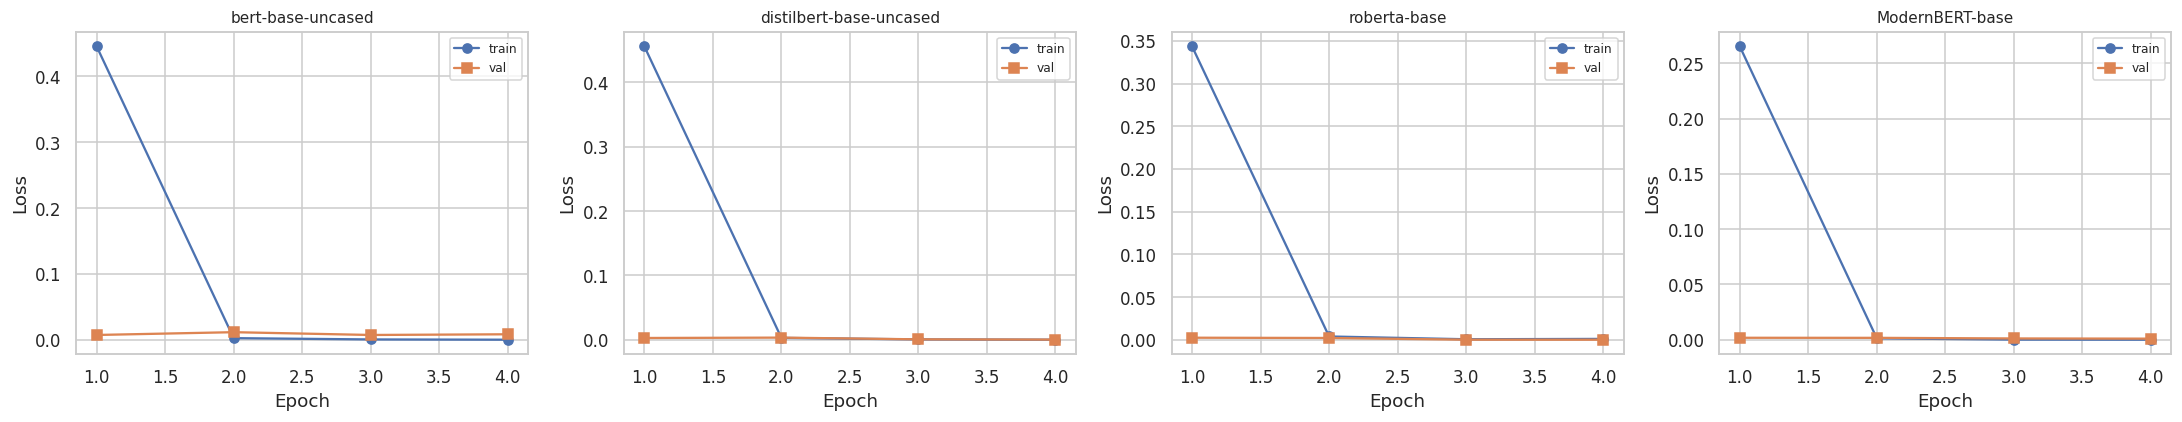

In [19]:
valid_encoders = {k: v for k, v in encoder_results.items() if "error" not in v}
n_models = len(valid_encoders)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, valid_encoders.items()):
    h = res["history"]
    epochs_range = range(1, len(h["train_loss"]) + 1)
    ax.plot(epochs_range, h["train_loss"], marker="o", label="train")
    ax.plot(epochs_range, h["val_loss"], marker="s", label="val")
    ax.set_title(name.split("/")[-1], fontsize=10)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("encoder_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.2 Best Encoder Model — Selection & Confusion Matrix

In [20]:
best_encoder_name = max(valid_encoders, key=lambda k: valid_encoders[k]["test_metrics"]["macro_f1"])
best_encoder_res = valid_encoders[best_encoder_name]
print(f"Best encoder (by test macro-F1): {best_encoder_name}")
print(f"  macro_f1={best_encoder_res['test_metrics']['macro_f1']:.4f}")
print(f"  accuracy={best_encoder_res['test_metrics']['accuracy']:.4f}")
print(f"  peak_mem={best_encoder_res['peak_mem_mb']:.0f}MB")
print(f"  latency={best_encoder_res['latency']['mean_ms']:.2f}ms")

Best encoder (by test macro-F1): distilbert-base-uncased
  macro_f1=1.0000
  accuracy=1.0000
  peak_mem=580MB
  latency=4.70ms


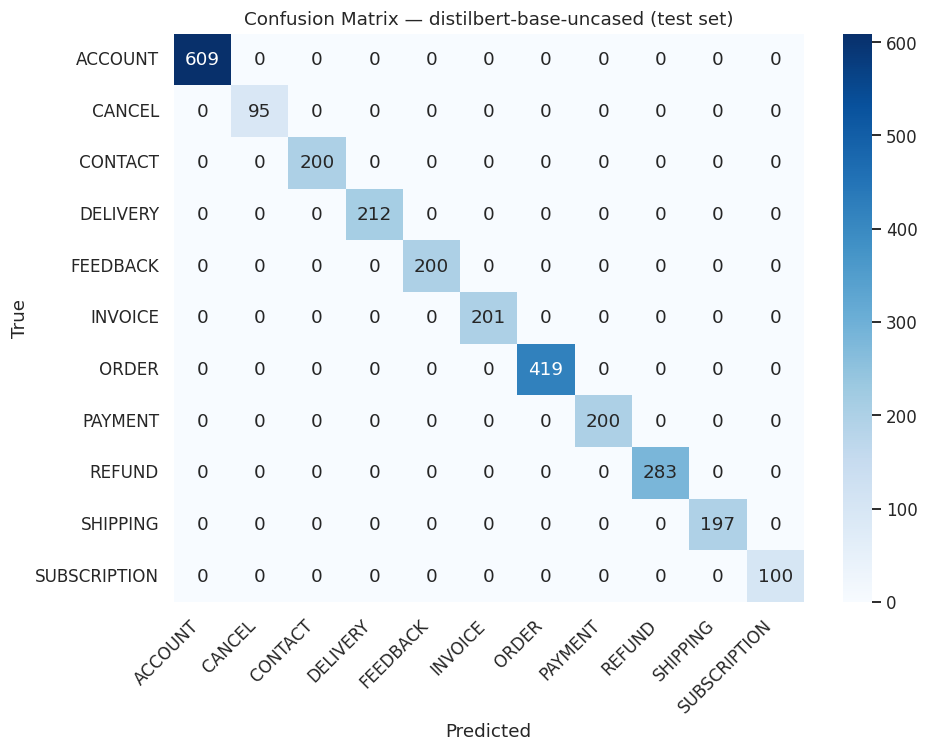

In [21]:
cm = best_encoder_res["test_metrics"]["confusion_matrix"]
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=categories, yticklabels=categories, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_encoder_name} (test set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("encoder_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
print(classification_report(
    best_encoder_res["test_metrics"]["labels"],
    best_encoder_res["test_metrics"]["preds"],
    target_names=categories, zero_division=0
))

              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00       609
      CANCEL       1.00      1.00      1.00        95
     CONTACT       1.00      1.00      1.00       200
    DELIVERY       1.00      1.00      1.00       212
    FEEDBACK       1.00      1.00      1.00       200
     INVOICE       1.00      1.00      1.00       201
       ORDER       1.00      1.00      1.00       419
     PAYMENT       1.00      1.00      1.00       200
      REFUND       1.00      1.00      1.00       283
    SHIPPING       1.00      1.00      1.00       197
SUBSCRIPTION       1.00      1.00      1.00       100

    accuracy                           1.00      2716
   macro avg       1.00      1.00      1.00      2716
weighted avg       1.00      1.00      1.00      2716

